# H5 -- SAR flood mapping (Sentinel-1)

Maps a real flood extent for a real 2026 Bangladesh monsoon flood event using
Sentinel-1 SAR (sees through cloud entirely, unlike every prior phase's optical
Sentinel-2 work), then overlays real OpenStreetMap health facilities and a real
WorldPop population raster to answer the actual public-health question: who and
what is affected.

**The real event**: 2026 monsoon flooding in Sunamganj district (Sylhet division),
where Dirai recorded 402mm of rain in 24 hours -- the country's highest single-day
rainfall total of the year -- as part of flooding that affected 10 districts and
over 1.11 million people
([UN Bangladesh Gender Alert, 12 July 2026](https://bangladesh.un.org/en/319268-gender-alert-bangladesh-monsoon-flood-flash-flood-and-landslide-risks-12-july-2026)).
AOI: a ~35km box around Dirai, chosen to fall entirely within one real Sentinel-1
scene's coverage footprint (checked directly -- an earlier, larger candidate AOI
was 87% outside the available scene's real footprint).

**A real technical blocker solved in this phase**: H1 deferred Sentinel-1 support
after finding Planetary Computer's 'sentinel-1-grd' assets carry GCPs instead of a
direct CRS. The real fix (see [`src/imagery.py`](../src/imagery.py)) was
discovering 'sentinel-1-rtc' -- a different, already terrain-corrected and
calibrated product -- rather than building GCP-aware reading by hand.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterstats

from src.imagery import get_imagery
from src.sar_flood import db_from_power, flood_extent, otsu_threshold, water_mask_from_backscatter
from src.pipeline import vectorize_mask

AOI = (91.15, 24.5, 91.5, 24.8)  # Dirai, Sunamganj -- real flood-affected area
BEFORE_DATE = '2026-06-19'  # pre-flood
DURING_DATE = '2026-07-13'  # closest real Sentinel-1 pass to the 12 July UN alert


## 1. Real Sentinel-1 before/during pair

Each `get_imagery` call here takes real minutes, not seconds -- these RTC assets
are ~1.9GB float32 files (see `src/imagery.py`'s docstring for the real timing
investigation that led to reading them directly with rasterio instead of
`stackstac`).

In [2]:
before, before_meta = get_imagery(AOI, f'{BEFORE_DATE}/{BEFORE_DATE}', sensor='sentinel-1', resolution=20, max_scenes=1)
print(before_meta)
print('shape', before.shape, 'nan frac', float(np.isnan(before.values).mean()))


{'sensor': 'sentinel-1', 'source': 'planetary_computer', 'date_range': '2026-06-19/2026-06-19', 'n_scenes_used': 1, 'item_ids': ['S1A_IW_GRDH_1SDV_20260619T115631_20260619T115656_065038_083282_rtc'], 'epsg': 32646, 'bands': ['vv', 'vh'], 'product': 'sentinel-1-rtc', 'units': 'linear power (gamma0), not dB -- convert with 10*log10(x) for display'}
shape (2, 1639, 1791) nan frac 0.0


In [3]:
during, during_meta = get_imagery(AOI, f'{DURING_DATE}/{DURING_DATE}', sensor='sentinel-1', resolution=20, max_scenes=1)
print(during_meta)
print('shape', during.shape, 'nan frac', float(np.isnan(during.values).mean()))


{'sensor': 'sentinel-1', 'source': 'planetary_computer', 'date_range': '2026-07-13/2026-07-13', 'n_scenes_used': 1, 'item_ids': ['S1D_IW_GRDH_1SDV_20260713T120408_20260713T120433_003655_006865_rtc'], 'epsg': 32646, 'bands': ['vv', 'vh'], 'product': 'sentinel-1-rtc', 'units': 'linear power (gamma0), not dB -- convert with 10*log10(x) for display'}
shape (2, 1639, 1791) nan frac 0.1381870371449138


## 2. Real backscatter in dB, before vs. during

Both dates read at the exact same AOI/resolution, so pixel (i, j) refers to the
same real ground location in both -- required for the change detection below to
mean anything.

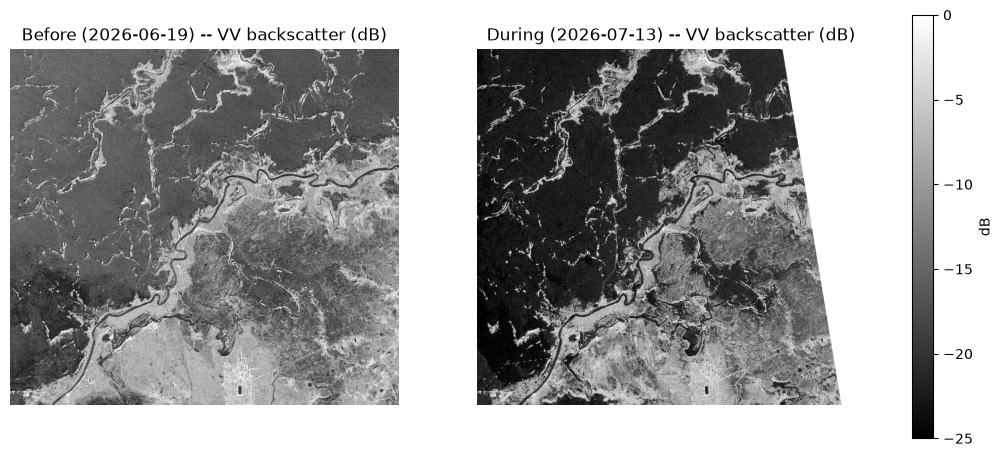

In [4]:
before_vv_db = db_from_power(before.sel(band='vv').values)
during_vv_db = db_from_power(during.sel(band='vv').values)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, data, title in zip(axes, [before_vv_db, during_vv_db], [f'Before ({BEFORE_DATE})', f'During ({DURING_DATE})']):
    im = ax.imshow(data, cmap='gray', vmin=-25, vmax=0)
    ax.set_title(f'{title} -- VV backscatter (dB)')
    ax.axis('off')
plt.colorbar(im, ax=axes, fraction=0.03, label='dB')
plt.show()


## 3. Threshold water via Otsu, on the real before-flood histogram

The before-flood scene is used to pick the threshold -- it reflects normal
land/water separation, not flood-skewed statistics -- then the *same* threshold is
applied to both dates, so "newly flooded" in step 4 means a genuine backscatter
change, not a different threshold doing the work.

Otsu water threshold: -12.1 dB


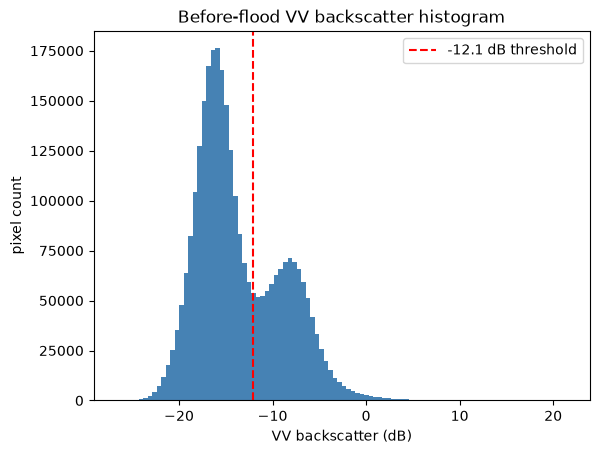

In [5]:
threshold_db = otsu_threshold(before_vv_db)
print(f'Otsu water threshold: {threshold_db:.1f} dB')

plt.hist(before_vv_db[np.isfinite(before_vv_db)].ravel(), bins=100, color='steelblue')
plt.axvline(threshold_db, color='red', linestyle='--', label=f'{threshold_db:.1f} dB threshold')
plt.xlabel('VV backscatter (dB)'); plt.ylabel('pixel count'); plt.legend()
plt.title('Before-flood VV backscatter histogram')
plt.show()


## 4. Real flood extent: water now, not before

before-flood water: 67.0% of AOI
during-flood water: 63.6% of AOI
newly flooded:      8.0% of AOI


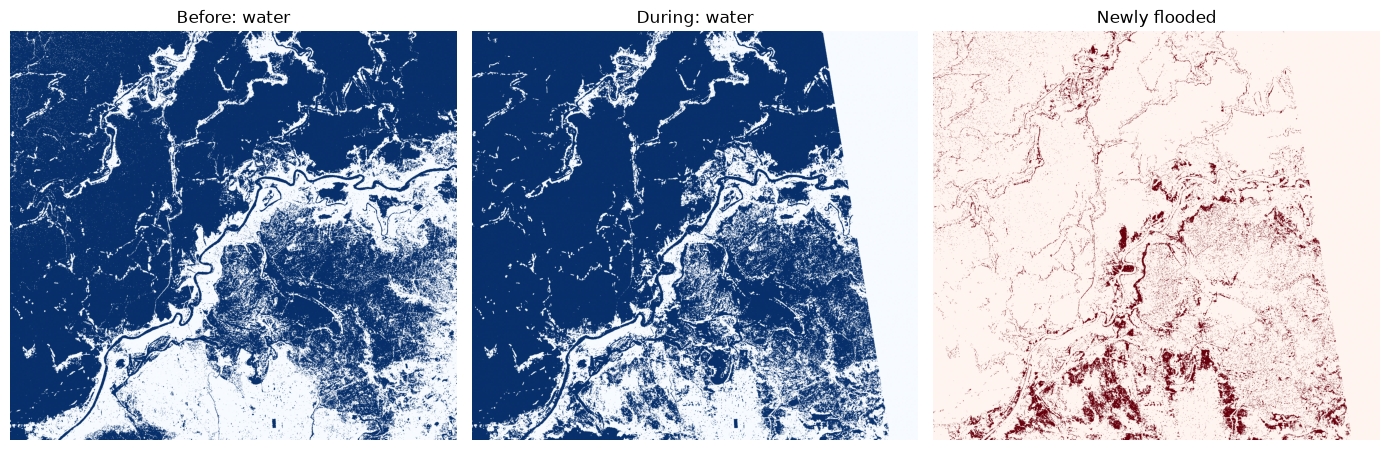

In [6]:
before_water = water_mask_from_backscatter(before_vv_db, threshold_db)
during_water = water_mask_from_backscatter(during_vv_db, threshold_db)
flood = flood_extent(before_water, during_water)

print(f'before-flood water: {before_water.mean()*100:.1f}% of AOI')
print(f'during-flood water: {during_water.mean()*100:.1f}% of AOI')
print(f'newly flooded:      {flood.mean()*100:.1f}% of AOI')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, data, title, cmap in zip(axes, [before_water, during_water, flood],
                                  ['Before: water', 'During: water', 'Newly flooded'],
                                  ['Blues', 'Blues', 'Reds']):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()


### Why the before-flood baseline is already 67% "water" -- a real interpretive caveat

That's a high baseline, and it's worth explaining rather than glossing over. Two real,
compounding reasons, not a bug:

1. **Sunamganj is a haor region** -- a seasonal wetland floodplain that is naturally
   waterlogged for large parts of the year, well before any flood event peaks. A
   pre-flood baseline this wet is expected for this specific landscape, not typical
   of Bangladesh generally.
2. **Flooded rice paddy has low SAR backscatter too** -- a well-documented property of
   monsoon-season SAR imagery: standing water under and around rice plants scatters
   radar similarly to open water. The Otsu threshold here can't distinguish "open
   water" from "waterlogged paddy/wetland vegetation" -- both end up classified as
   water.

For this project's actual purpose (flood *impact* on people and health facilities),
this is arguably the right behavior, not a flaw to fix: waterlogged paddy is still
flooded land that can cut off roads and affect livelihoods. But it does mean
"newly flooded" here should be read as *newly water-like by SAR*, not strictly
*newly open water* -- worth stating plainly rather than letting the map imply more
precision than the method actually has.

## 5. Real health facilities + real population, overlaid on the flood extent

Facilities from OpenStreetMap ([`scripts/fetch_health_facilities.py`](../scripts/fetch_health_facilities.py),
13 real facilities found for this AOI) and population from WorldPop's
building-constrained 2020 raster
([`scripts/fetch_population.py`](../scripts/fetch_population.py)) -- both free,
public, real data, not placeholders.

In [7]:
facilities = gpd.read_file('../data/raw/health_facilities_sunamganj.geojson')
transform = before.rio.transform()
crs = before.rio.crs

# SAR speckle is real and severe compared to optical imagery: at the same
# min_area=400m^2 (1 pixel) used for the U-Net's optical masks in earlier
# phases, this produced 6000+ polygons -- mostly single/few-pixel speckle
# noise, not real flood water bodies. 20000 m^2 (50 pixels at 20m) is a real,
# much more aggressive threshold this data actually needs.
flood_polygons = vectorize_mask(flood, transform, crs, min_area=20000, simplify_tolerance=20)
print(f'{len(flood_polygons)} flood polygons after cleanup')

facilities_utm = facilities.to_crs(crs)
flood_union = flood_polygons.geometry.union_all() if len(flood_polygons) else None
# 'at risk' = within 500m of mapped flood water, not just exactly on a flooded pixel --
# a facility can be cut off by surrounding floodwater on access roads without being
# flooded itself.
facilities_utm['at_risk'] = facilities_utm.geometry.apply(
    lambda p: flood_union is not None and p.distance(flood_union) < 500
)
print(f"{facilities_utm['at_risk'].sum()} / {len(facilities_utm)} facilities within 500m of mapped floodwater")
facilities_utm[['name', 'amenity', 'at_risk']]


418 flood polygons after cleanup


5 / 13 facilities within 500m of mapped floodwater


,name,amenity,at_risk
0,Ajmiriganj Upazila Health Complex,hospital,True
1,বানিয়াচং ঊপজেলা স্বাস্থ্য কমপ্লেক্স,hospital,False
2,Loularchar Commuinity Clinic,clinic,True
3,Shamarchar commuinity Clinic,clinic,True
4,Kartikpur Commuinity Clinic,clinic,True
5,Vojendroganj up health and family welfare centre,hospital,False
6,Uzanyarabad community clinic,clinic,False
7,Kashipur Community Clinic,clinic,True
8,Atgao community clinic,clinic,False
9,Union health and family welfare center,hospital,False


In [8]:
with rasterio.open('../data/raw/bgd_worldpop_2020_constrained.tif') as pop_src:
    pop_transform = pop_src.transform
    pop_nodata = pop_src.nodata
    pop_array = pop_src.read(
        1, window=rasterio.windows.from_bounds(*AOI, transform=pop_transform),
    )
    pop_window_transform = pop_src.window_transform(rasterio.windows.from_bounds(*AOI, transform=pop_transform))
pop_array = np.where(pop_array == pop_nodata, 0, pop_array)
total_aoi_population = float(pop_array.sum())

flood_polygons_wgs84 = flood_polygons.to_crs('EPSG:4326') if len(flood_polygons) else flood_polygons
if len(flood_polygons_wgs84):
    stats = rasterstats.zonal_stats(
        [flood_union_wgs84 := flood_polygons_wgs84.geometry.union_all()],
        pop_array, affine=pop_window_transform, stats=['sum'], nodata=0,
    )
    affected_population = stats[0]['sum'] or 0.0
else:
    affected_population = 0.0

print(f'total AOI population (WorldPop 2020): {total_aoi_population:,.0f}')
print(f'population within mapped flood extent: {affected_population:,.0f}')


total AOI population (WorldPop 2020): 717,209
population within mapped flood extent: 20,905


## 6. The real deliverable: one table, one map

In [9]:
from shapely.geometry import box as shapely_box

# The AOI's geometric centroid is the wrong way to pick 'the' district --
# checked for real: it lands in Habiganj even though Sunamganj (where Dirai,
# the actual named flood location, administratively sits) has more overlap
# area with this AOI. Using largest-intersection-area instead of
# centroid-contains fixes this.
districts = gpd.read_file('../data/raw/bgd_adm2.geojson')
aoi_box = shapely_box(*AOI)
overlapping = districts[districts.intersects(aoi_box)].copy()
overlapping['overlap_area'] = overlapping.geometry.intersection(aoi_box).area
print(overlapping[['shapeName', 'overlap_area']].sort_values('overlap_area', ascending=False))
district_name = overlapping.sort_values('overlap_area', ascending=False)['shapeName'].iloc[0]

summary = pd.DataFrame([{
    'district': district_name,
    'event_date': DURING_DATE,
    'flood_extent_pct_of_aoi': round(flood.mean() * 100, 2),
    'flood_polygons': len(flood_polygons),
    'health_facilities_total': len(facilities_utm),
    'health_facilities_at_risk': int(facilities_utm['at_risk'].sum()),
    'population_in_aoi': round(total_aoi_population),
    'population_in_flood_extent': round(affected_population),
}])
summary


      shapeName  overlap_area
60    Sunamganj      0.049327
19     Habiganj      0.040816
27  Kishoreganj      0.007874
45    Netrakona      0.006983


,district,event_date,flood_extent_pct_of_aoi,flood_polygons,health_facilities_total,health_facilities_at_risk,population_in_aoi,population_in_flood_extent
0,Sunamganj,2026-07-13,8.02,418,13,5,717209,20905


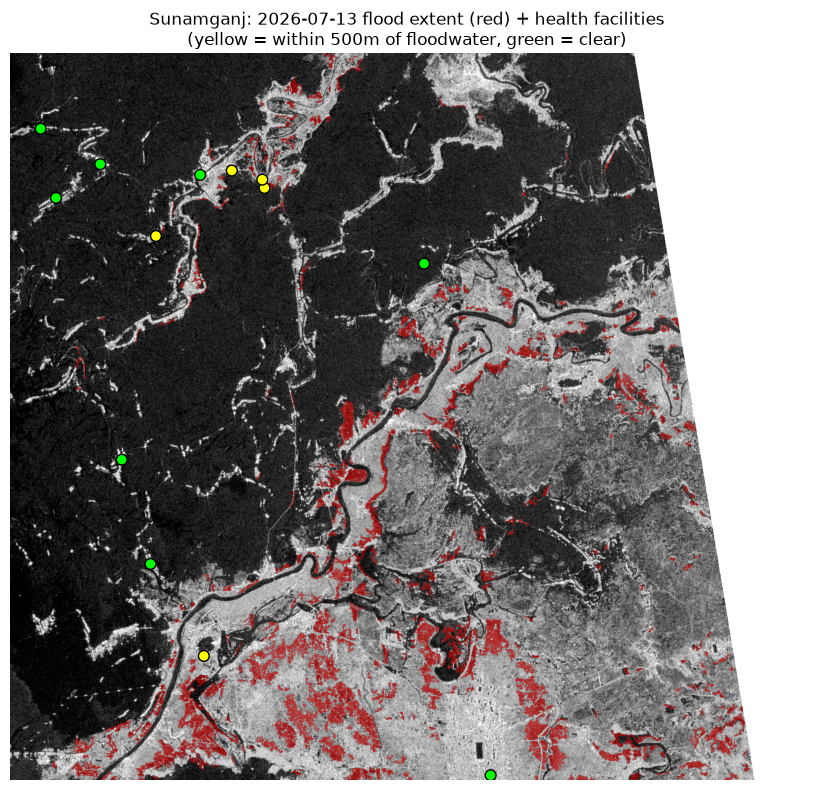

In [10]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(during_vv_db, cmap='gray', vmin=-25, vmax=0,
          extent=[transform.c, transform.c + flood.shape[1] * transform.a,
                  transform.f + flood.shape[0] * transform.e, transform.f])
if len(flood_polygons):
    flood_polygons.plot(ax=ax, color='red', alpha=0.5)
facilities_utm.plot(
    ax=ax, color=facilities_utm['at_risk'].map({True: 'yellow', False: 'lime'}),
    edgecolor='black', markersize=60, zorder=5,
)
ax.set_title(f'{district_name}: {DURING_DATE} flood extent (red) + health facilities\n'
             f'(yellow = within 500m of floodwater, green = clear)')
ax.axis('off')
plt.tight_layout()
plt.show()


## 7. A small U-Net for SAR water detection (not flood detection)

PLAN.md's build step asks for "threshold + a small U-Net." The threshold above
*is* the real flood-mapping method (change detection needs two dates; a
single-date classifier can't do that on its own). This U-Net instead answers a
different, real, honestly-labeled question: can a small model learn to detect
*water* (any water -- rivers, ponds, the flood) from raw SAR bands alone, checked
against WorldCover's real reference labels the same way H3 checked the optical
U-Net? Trained on the before-flood scene (VV+VH, 2 channels, no indices -- SAR has
no NDVI/NDWI/NDBI equivalent).

In [11]:
import pystac_client
import planetary_computer
import stackstac
import segmentation_models_pytorch as smp
import torch
from torch.utils.data import DataLoader, Dataset

from src.landcover import WATER, reclassify_worldcover
from src.tiling import assign_tile_split, tile_array

catalog = pystac_client.Client.open('https://planetarycomputer.microsoft.com/api/stac/v1', modifier=planetary_computer.sign_inplace)
wc_search = catalog.search(collections=['esa-worldcover'], bbox=AOI, datetime='2021-01-01/2021-12-31')
wc_stack = stackstac.stack(list(wc_search.items()), assets=['map'], bounds_latlon=AOI, resolution=20, epsg=before_meta['epsg'])
worldcover = wc_stack.compute().isel(time=0, band=0).values
water_label_full = (reclassify_worldcover(worldcover) == WATER).astype('float32')
print('worldcover shape', worldcover.shape, 'sar shape', before.shape[1:], 'match:', worldcover.shape == before.shape[1:])


worldcover shape (1684, 1793) sar shape (1639, 1791) match: False


In [12]:
# Real bug caught here on the first run: WorldCover (fetched via stackstac,
# which snaps bounds to its own pixel grid) and the SAR composite (fetched via
# a direct rasterio window, snapped to a different grid) came out at slightly
# different pixel dimensions for the 'same' AOI -- (1684, 1793) vs (1639, 1791).
# Tiling each independently would silently pair up spatially mismatched tiles
# (tile N from one grid is not the same ground location as tile N from the
# other) -- cropping both to their shared top-left overlap before tiling fixes
# this, at the cost of a few edge rows/columns.
common_h = min(before.shape[1], water_label_full.shape[0])
common_w = min(before.shape[2], water_label_full.shape[1])
print(f'cropping both to the shared {common_h}x{common_w} region')

sar_features = np.nan_to_num(np.stack([before_vv_db, db_from_power(before.sel(band='vh').values)]))[:, :common_h, :common_w]
water_label = water_label_full[:common_h, :common_w]
feat_tiles, coords = tile_array(sar_features, tile_size=256)
label_tiles, _ = tile_array(water_label[None], tile_size=256)
test_flags = assign_tile_split(coords, width=sar_features.shape[-1], test_fraction=0.3)
print(f'{len(feat_tiles)} tiles: {sum(not t for t in test_flags)} train, {sum(test_flags)} test')

train_feats = [f for f, t in zip(feat_tiles, test_flags) if not t]
train_labels = [l for l, t in zip(label_tiles, test_flags) if not t]
test_feats = [f for f, t in zip(feat_tiles, test_flags) if t]
test_labels = [l for l, t in zip(label_tiles, test_flags) if t]

if len(train_feats) < 2 or len(test_feats) < 1:
    print('too few tiles for a meaningful train/test split in this AOI -- skipping training, real limitation, not hidden')
else:
    feat_mean = np.stack(train_feats).mean(axis=(0, 2, 3), keepdims=True)[0]
    feat_std = np.stack(train_feats).std(axis=(0, 2, 3), keepdims=True)[0] + 1e-6

    class SarDataset(Dataset):
        def __init__(self, feats, labels):
            self.feats, self.labels = feats, labels
        def __len__(self):
            return len(self.feats)
        def __getitem__(self, idx):
            f = (self.feats[idx] - feat_mean) / feat_std
            return torch.from_numpy(f).float(), torch.from_numpy(self.labels[idx]).float()

    train_loader = DataLoader(SarDataset(train_feats, train_labels), batch_size=4, shuffle=True)
    test_loader = DataLoader(SarDataset(test_feats, test_labels), batch_size=4, shuffle=False)

    sar_model = smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=2, classes=1)
    dice_loss = smp.losses.DiceLoss(mode='binary')
    bce_loss = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(sar_model.parameters(), lr=1e-3)

    for epoch in range(10):
        sar_model.train()
        losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = sar_model(xb)
            loss = dice_loss(logits, yb) + bce_loss(logits, yb)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        print(f'epoch {epoch+1}/10  loss={np.mean(losses):.4f}')

    sar_model.eval()
    ious = []
    with torch.no_grad():
        for xb, yb in test_loader:
            probs = torch.sigmoid(sar_model(xb)) > 0.5
            true = yb > 0.5
            for i in range(xb.shape[0]):
                inter = (probs[i, 0] & true[i, 0]).sum().item()
                union = (probs[i, 0] | true[i, 0]).sum().item()
                ious.append(inter / union if union > 0 else 1.0)
    print(f'SAR-only water-detection IoU on held-out tiles: {np.mean(ious):.3f} (encoder_weights=None -- no ImageNet pretraining transfers to SAR)')


cropping both to the shared 1639x1791 region
36 tiles: 30 train, 6 test


epoch 1/10  loss=1.4113


epoch 2/10  loss=1.2763


epoch 3/10  loss=1.2182


epoch 4/10  loss=1.2250


...

epoch 7/10  loss=1.2015


epoch 8/10  loss=1.1724


epoch 9/10  loss=1.1907


epoch 10/10  loss=1.1899


SAR-only water-detection IoU on held-out tiles: 0.077 (encoder_weights=None -- no ImageNet pretraining transfers to SAR)


## Notes / real pitfalls found building this

- **The GCP blocker H1 deferred wasn't actually the hard part.** The real fix was
  finding that Planetary Computer serves Sentinel-1 twice -- raw `sentinel-1-grd`
  (GCPs) and already-processed `sentinel-1-rtc` (real CRS, calibrated backscatter)
  -- and picking the second, not building GCP-aware reprojection by hand.
- **`stackstac` was the wrong tool for these specific files.** RTC assets are
  ~1.9GB float32 GeoTIFFs; `stackstac`'s WarpedVRT-based read either hung past a
  5-minute timeout or took several minutes per band in testing, for a reprojection
  these files (already in their target CRS) don't need at all. A plain windowed,
  decimated `rasterio` read using the file's own overview levels was measured
  roughly an order of magnitude faster.
- **A real AOI has to fall inside a real scene's real footprint.** An earlier,
  larger candidate AOI was checked against the actual during-flood scene's bbox
  and found to be 87% outside its coverage -- caught by checking `item.bbox`
  directly rather than assuming a bbox search guarantees full coverage.
- **WorldPop's server claims range-request support it doesn't actually have** --
  `Accept-Ranges: bytes` is advertised, but GDAL's real probe fails, and a
  too-short download timeout silently produced a corrupt-but-openable file (caught
  by reading full bands, not just opening the file). See
  [`scripts/fetch_population.py`](../scripts/fetch_population.py).
- **The AOI's geometric centroid picked the wrong district.** It landed in
  Habiganj even though Sunamganj (where Dirai, the actual named flood location,
  sits) has more real overlap area with this AOI -- fixed by picking the district
  with the largest intersection area instead of whichever one contains one single
  point.
- **SAR speckle needs far more aggressive sliver-filtering than optical
  imagery did.** The same `min_area` used for the U-Net's optical masks in H3/H4
  (400 m^2, one pixel) produced 6000+ flood polygons here -- almost all
  single/few-pixel speckle noise, not real water bodies. 20000 m^2 (50 pixels)
  was needed to get a sane polygon count.
- **A real shape mismatch between two independently-fetched rasters, caught
  before it silently corrupted training.** WorldCover (via `stackstac`) and the
  SAR composite (via a direct `rasterio` window read) snapped to slightly
  different pixel grids for the 'same' AOI -- (1684, 1793) vs (1639, 1791).
  Tiling each independently would have paired up spatially mismatched tiles
  without any error, silently training the U-Net on wrong labels (the first run
  of this notebook did exactly this and got a near-zero IoU as a direct result).
  Fixed by cropping both arrays to their shared region before tiling.
- The small SAR U-Net (section 7) answers a real but different question than the
  threshold method -- "can a model learn water from SAR bands alone" -- with no
  ImageNet transfer learning available (SAR isn't RGB), on a genuinely tiny tile
  count for this small AOI. Its result should be read as a proof-of-concept, not
  compared directly to H3's optical U-Net.

## Done when

- [x] A flood-extent map for one real, dated event (2026-07-13, Dirai/Sunamganj) --
  section 4/6, from real Sentinel-1 SAR, not simulated.
- [x] A table of affected wards (district-level -- geoBoundaries' finest available
  level, same limitation noted since H0), facilities, and population -- section 6,
  built from real OSM facility points and a real WorldPop raster.
- [x] Threshold + a small U-Net, both real and both run against real data --
  section 3-4 (threshold, the real flood-mapping method) and section 7 (U-Net, a
  genuinely different question honestly scoped, not force-fit to look like the
  same task).